In [1]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 65.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 32.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 94.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 10.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!pip install seaborn

In [3]:
import json
import math
import os
import random
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

In [4]:
def _balanced_singular_values(singular_values: np.ndarray,
                              lmda: float) -> Tuple[np.ndarray, np.ndarray]:
    """
       Numerically stable construction of a, b satisfying
                 a_i * b_i = s_i
                 a_i^2 - b_i^2 = lambda

       Here:
                 a belongs to W_K, WO
                 b belongs to W_Q, WV

       Therefore lambda > 0 is key-heavy under

                 W_K.T @ W_K - W_Q.T @ W_Q = lambda I.
    """
    s = np.asarray(singular_values, dtype=np.float64)

    # More stable than sqrt(lambda**2 + 4*s**2).
    root = np.hypot(float(lmda), 2.0 * s) # computes the hypotenuse

    if lmda >= 0:
        # This branch computes the large factor directly.
        a = np.sqrt(0.5 * (root + lmda))

        # Compute the small factor from ab=s, avoiding
        # root - lambda catastrophic cancellation.
        b = np.divide(s,a,
                      out=np.zeros_like(s),where=a > 0)

    else:
        # When lambda < 0, b is the large factor.
        b = np.sqrt(0.5 * (root - lmda))

        # Compute the small factor from ab=s.
        a = np.divide(s,b,
                      out=np.zeros_like(s),where=b > 0)

    return a, b

In [5]:
def get_lambda_balanced_query_key(lmda: float,d_model: int,
                                  d_head: int,sigma: float = 1.0,
                                  seed: int = 42,) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
       Construct PyTorch-compatible key/query weights preserving

                          C_QK = W_K W_Q^T

       and imposing

                          W_K^T W_K - W_Q^T W_Q = lambda I_{d_head}.

       The theoretical matrices have shape
                          W_K, W_Q: (d_model, d_head).

       PyTorch nn.Linear stores their transposes: key_weight, query_weight: (d_head, d_model).

       Positive lambda is key-heavy.
    """
    if d_head > d_model:
        raise ValueError("The construction requires d_head <= d_model.")

    rng = np.random.default_rng(seed)

    std = sigma * np.sqrt(2.0 / d_model)

    # Theoretical base matrices.
    W_K_base = rng.standard_normal((d_model, d_head)).astype(np.float64) * std

    W_Q_base = rng.standard_normal((d_model, d_head)).astype(np.float64) * std

    # Effective QK product to preserve.
    C0 = W_K_base @ W_Q_base.T

    U, S, Vt = np.linalg.svd(C0,full_matrices=False)

    # Internal orthogonal gauge.
    R_raw = rng.standard_normal((d_head, d_head)).astype(np.float64)

    R, _ = np.linalg.qr(R_raw)

    # Stable factor singular values:
    #
    # a_i b_i = S_i
    # a_i^2 - b_i^2 = lambda
    a, b = _balanced_singular_values(S[:d_head],lmda,)

    # W_K = U diag(a) R^T
    # W_Q = V diag(b) R^T
    W_K = (U[:, :d_head]@ np.diag(a)@ R.T)

    W_Q = (Vt.T[:, :d_head]@ np.diag(b)@ R.T)

    # PyTorch nn.Linear storage orientation.
    key_weight = W_K.T
    query_weight = W_Q.T

    return key_weight, query_weight, C0

In [6]:
wk, wq, c = get_lambda_balanced_query_key(0,50,50)
np.linalg.norm(wk@wk.T - wq@wq.T,ord="fro")

np.float64(3.96114611026968e-14)

In [7]:
def get_lambda_balanced_output_value(lmda: float,d_model: int,
                                     d_value: int,d_out: int,sigma: float = 1.0,
                                     seed: int = 42) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
       Construct W_O and W_V while preserving

                   C_OV = W_O W_V

       and imposing

                 W_O^T W_O - W_V W_V^T = lambda I_{d_value}.

       Shapes
       ------
      W_V: (d_value, d_model)

      W_O: (d_out, d_value)

      C_OV: (d_out, d_model)

      Sign convention
      ---------------
      lambda > 0: output-heavy

      lambda < 0:value-heavy

      Returns
      -------
      init_wo: Directly assignable to prediction_layer.weight.

      init_wv: Directly assignable to value_layer.weight.

      c0: Preserved effective OV product.
    """
    if d_value > min(d_model, d_out):
        raise ValueError("This construction requires " "d_value <= min(d_model, d_out).")

    rng = np.random.default_rng(seed)

    std_v = sigma * np.sqrt(2.0 / d_model)
    std_o = sigma * np.sqrt(2.0 / d_value)

    # These shapes are already PyTorch nn.Linear storage shapes.
    wv_base = (rng.standard_normal((d_value, d_model)).astype(np.float64)* std_v)

    wo_base = (
        rng.standard_normal((d_out, d_value))
        .astype(np.float64)
        * std_o
    )

    # Effective product to preserve.
    c0 = wo_base @ wv_base

    U, S, Vt = np.linalg.svd(c0,full_matrices=False,)

    R_raw = rng.standard_normal((d_value, d_value)).astype(np.float64)

    R, _ = np.linalg.qr(R_raw)

    # a belongs to W_O and b belongs to W_V:
    #
    # a_i b_i = S_i
    # a_i^2 - b_i^2 = lambda
    a, b = _balanced_singular_values(S[:d_value],lmda)

    # W_O = U diag(a) R^T
    init_wo = (U[:, :d_value]@ np.diag(a)@ R.T)

    # W_V = R diag(b) V^T
    init_wv = (R@ np.diag(b)@ Vt[:d_value, :])

    return init_wo, init_wv, c0

In [8]:
wo, wv, wov = get_lambda_balanced_output_value(100,50,50,100)
np.linalg.norm(wo.T@wo - wv@wv.T,ord="fro") 

np.float64(707.1067811865476)

In [9]:
class Net_p1(nn.Module):
    """
        Single-head self-attention model with lambda-balanced
        QK and OV initialization.

        QK convention
        -------------
        The theoretical matrices are W_K, W_Q in R^{d_model x d_head} and the effective QK circuit is

                                     C_QK = W_K W_Q^T.

        PyTorch stores key_layer.weight   = W_K^T query_layer.weight = W_Q^T.

        Therefore, using stored tensors,

                                     C_QK = K_store^T Q_store
        and the balancedness invariant is

                    Delta_QK = W_K^T W_K - W_Q^T W_Q = K_store K_store^T - Q_store Q_store^T.

        OV convention
        -------------
        PyTorch directly stores value_layer.weight      = W_V prediction_layer.weight = W_O.

        Therefore,

                    C_OV = W_O W_V and  Delta_OV = W_O^T W_O - W_V W_V^T.
    """

    def __init__( self, lmda_qk: float,lmda_ov: float, seed: int,
                 d_model: int = 50,d_head: int = 50,
                 d_value: int = 50,d_out: int = 50,
                 sigma_qk: float = 1.0,sigma_ov: float = 1.0):
        super().__init__()

        self.d_model = d_model
        self.d_head = d_head
        self.d_value = d_value
        self.d_out = d_out

        self.lmda_qk = float(lmda_qk)
        self.lmda_ov = float(lmda_ov)

        # ---------------------------------------------------------
        # Layers
        # ---------------------------------------------------------

        self.key_layer = nn.Linear(d_model,d_head,bias=False)

        self.query_layer = nn.Linear(d_model,d_head,bias=False)

        self.value_layer = nn.Linear(d_model,d_value,bias=False)

        self.prediction_layer = nn.Linear(d_value,d_out,bias=False)

        # ---------------------------------------------------------
        # Construct balanced QK factors
        # ---------------------------------------------------------

        init_wk, init_wq, target_qk_product = get_lambda_balanced_query_key(lmda=lmda_qk,d_model=d_model,
                                                                             d_head=d_head,sigma=sigma_qk,
                                                                             seed=seed)

        # Expected shapes: init_wk: (d_head, d_model) init_wq: (d_head, d_model)
        assert init_wk.shape == (d_head,d_model)

        assert init_wq.shape == (d_head,d_model)

        # ---------------------------------------------------------
        # Construct balanced OV factors
        # ---------------------------------------------------------

        init_wo, init_wv, target_ov_product = get_lambda_balanced_output_value(lmda=lmda_ov,d_model=d_model,
                                                                               d_value=d_value,d_out=d_out,
                                                                               sigma=sigma_ov,seed=seed)
    

        # Expected shapes: init_wo: (d_out, d_value) init_wv: (d_value, d_model)
        assert init_wo.shape == (d_out,d_value)

        assert init_wv.shape == (d_value,d_model)

        # ---------------------------------------------------------
        # Copy arrays into the existing Parameters
        # ---------------------------------------------------------

        with torch.no_grad():
            self.key_layer.weight.copy_(torch.as_tensor(init_wk,
                                                        dtype=self.key_layer.weight.dtype,
                                                        device=self.key_layer.weight.device))

            self.query_layer.weight.copy_(torch.as_tensor(init_wq,
                                                          dtype=self.query_layer.weight.dtype,
                                                          device=self.query_layer.weight.device))

            self.value_layer.weight.copy_(torch.as_tensor(init_wv,
                                                          dtype=self.value_layer.weight.dtype,
                                                          device=self.value_layer.weight.device))

            self.prediction_layer.weight.copy_(torch.as_tensor(init_wo,
                                                               dtype=self.prediction_layer.weight.dtype,
                                                               device=self.prediction_layer.weight.device))

        # ---------------------------------------------------------
        # Store the desired products from the NumPy construction
        # ---------------------------------------------------------

        self.register_buffer("target_qk_product",torch.as_tensor(target_qk_product,
                                                                 dtype=self.key_layer.weight.dtype))

        self.register_buffer("target_ov_product",torch.as_tensor(target_ov_product,
                                                                 dtype=self.value_layer.weight.dtype))

        # ---------------------------------------------------------
        # Store the actual post-casting initialization These are the quantities that should be used to measure
        # movement and finite-step invariant drift.
        # ---------------------------------------------------------

        with torch.no_grad():
            qk_product_0 = self.get_qk_product()
            qk_balance_0 = self.get_qk_balance()

            ov_product_0 = self.get_ov_product()
            ov_balance_0 = self.get_ov_balance()

        self.register_buffer("initial_qk_product",qk_product_0.detach().clone())

        self.register_buffer("initial_qk_balance",qk_balance_0.detach().clone())

        self.register_buffer("initial_ov_product",ov_product_0.detach().clone())

        self.register_buffer("initial_ov_balance",ov_balance_0.detach().clone())

    # =============================================================
    # QK accessors
    # =============================================================

    def get_qk_product(self) -> torch.Tensor:
        """
           Effective circuit C_QK = W_K W_Q^T.

           PyTorch stores

                      K_store = W_K^T
                      Q_store = W_Q^T,

           hence C_QK = K_store^T Q_store.
        """
        k_store = self.key_layer.weight
        q_store = self.query_layer.weight

        return k_store.T @ q_store

    def get_qk_balance(self) -> torch.Tensor:
        """
           Balancedness matrix Delta_QK = W_K^T W_K - W_Q^T W_Q.

           In PyTorch storage orientation, Delta_QK = K_store K_store^T - Q_store Q_store^T.
        """
        k_store = self.key_layer.weight
        q_store = self.query_layer.weight
        # As matrices are already in transpose form equivalent balanceness is kk.T - qq.T
        return (k_store @ k_store.T- q_store @ q_store.T)

    # =============================================================
    # OV accessors
    # =============================================================

    def get_ov_product(self) -> torch.Tensor:
        """
        Effective OV circuit C_OV = W_O W_V.
        """
        W_O = self.prediction_layer.weight
        W_V = self.value_layer.weight

        return W_O @ W_V

    def get_ov_balance(self) -> torch.Tensor:
        """
        Balancedness matrix Delta_OV = W_O^T W_O - W_V W_V^T.
        """
        W_O = self.prediction_layer.weight
        W_V = self.value_layer.weight

        return (W_O.T @ W_O - W_V @ W_V.T)

    # =============================================================
    # Initialization diagnostics
    # =============================================================

    @torch.no_grad()
    def verify_initialization(self) -> Dict[str, float]:
        """
        Verify the products and balancedness conditions after
        copying the NumPy matrices into the PyTorch model.
        """

        qk_product = self.get_qk_product()
        qk_balance = self.get_qk_balance()

        ov_product = self.get_ov_product()
        ov_balance = self.get_ov_balance()

        qk_target_balance = (self.lmda_qk* torch.eye(self.d_head,
                                                     dtype=qk_balance.dtype,
                                                     device=qk_balance.device))

        ov_target_balance = (self.lmda_ov* torch.eye(self.d_value,
                                                     dtype=ov_balance.dtype,
                                                     device=ov_balance.device))

        qk_product_relative_error = (torch.linalg.norm(qk_product-self.target_qk_product,
                                                       ord="fro")/torch.linalg.norm(self.target_qk_product,
                                                                                    ord="fro",).clamp_min(1e-30))

        ov_product_relative_error = (torch.linalg.norm(ov_product-self.target_ov_product,
                                                       ord="fro")/torch.linalg.norm(self.target_ov_product,
                                                                                      ord="fro").clamp_min(1e-30))

        qk_balance_absolute_error = torch.linalg.norm(qk_balance - qk_target_balance,ord="fro")

        ov_balance_absolute_error = torch.linalg.norm(ov_balance - ov_target_balance,ord="fro")

        # For lambda = 0 the target norm vanishes, so clamp to one.
        qk_balance_relative_error = (qk_balance_absolute_error/torch.linalg.norm(qk_target_balance,
                                                                                 ord="fro",).clamp_min(1.0))

        ov_balance_relative_error = (ov_balance_absolute_error/ torch.linalg.norm(ov_target_balance,
                                                                                  ord="fro",).clamp_min(1.0))

        metrics = {"qk_product_relative_error":qk_product_relative_error.item(),
                   "qk_balance_absolute_error":qk_balance_absolute_error.item(),
                   "qk_balance_relative_error":qk_balance_relative_error.item(),
                   "ov_product_relative_error":ov_product_relative_error.item(),
                   "ov_balance_absolute_error":ov_balance_absolute_error.item(),
                   "ov_balance_relative_error":ov_balance_relative_error.item()}

        for name, value in metrics.items():
            print(f"{name}: {value:.3e}")

        return metrics

    # =============================================================
    # Training-time diagnostics
    # =============================================================

    @torch.no_grad()
    def circuit_metrics(self) -> Dict[str, float]:
        """
        Return effective-product movement and balancedness drift.

        Product movement:
            ||C(t) - C(0)||

        Balancedness drift:
            ||Delta(t) - Delta(0)||
        """

        qk_product = self.get_qk_product()
        qk_balance = self.get_qk_balance()

        ov_product = self.get_ov_product()
        ov_balance = self.get_ov_balance()

        # ---------------------------------------------------------
        # Effective-product movement
        # ---------------------------------------------------------

        qk_product_abs_movement = torch.linalg.norm(qk_product - self.initial_qk_product,ord="fro")

        qk_product_rel_movement = (qk_product_abs_movement/ torch.linalg.norm(self.initial_qk_product,
                                                                              ord="fro").clamp_min(1e-30))

        ov_product_abs_movement = torch.linalg.norm(ov_product - self.initial_ov_product,ord="fro")

        ov_product_rel_movement = (ov_product_abs_movement/ torch.linalg.norm(self.initial_ov_product,
                                                                              ord="fro",).clamp_min(1e-30))

        # ---------------------------------------------------------
        # Balancedness drift
        # ---------------------------------------------------------

        qk_balance_abs_drift = torch.linalg.norm(qk_balance - self.initial_qk_balance,ord="fro")

        ov_balance_abs_drift = torch.linalg.norm(ov_balance - self.initial_ov_balance,ord="fro")

        # Gram-scale normalization also works when lambda = 0.
        K = self.key_layer.weight
        Q = self.query_layer.weight

        qk_gram_scale = (torch.linalg.norm(K @ K.T,ord="fro") + torch.linalg.norm( Q @ Q.T,ord="fro"))

        O = self.prediction_layer.weight
        V = self.value_layer.weight

        ov_gram_scale = (torch.linalg.norm(O.T @ O,ord="fro") + torch.linalg.norm(V @ V.T,ord="fro"))

        qk_balance_normalized_drift = (qk_balance_abs_drift / qk_gram_scale.clamp_min(1e-12))

        ov_balance_normalized_drift = (ov_balance_abs_drift/ ov_gram_scale.clamp_min(1e-12))

        return { 
            "qk_product_abs_movement": qk_product_abs_movement.item(),
            "qk_product_rel_movement": qk_product_rel_movement.item(),
            "qk_balance_abs_drift": qk_balance_abs_drift.item(),
            "qk_balance_normalized_drift": qk_balance_normalized_drift.item(),
            "ov_product_abs_movement": ov_product_abs_movement.item(),
            "ov_product_rel_movement": ov_product_rel_movement.item(),
            "ov_balance_abs_drift": ov_balance_abs_drift.item(),
            "ov_balance_normalized_drift": ov_balance_normalized_drift.item() }

    # =============================================================
    # Forward
    # =============================================================

    def forward(self, x):
        """
        x: (batch, sequence_length, d_model)
        """

        batch, seq_len, vocab_size = x.shape

        # key_i = x_i W_K
        key = self.key_layer(x)

        # query = x_last W_Q
        query = self.query_layer(x[:, -1, :]).unsqueeze(1)

        # This computes (x_query W_Q)(x_i W_K)^T which is a scalar equal to x_i W_K W_Q^T x_query^T.
        scores = ( query @ key.transpose(-2, -1)) / math.sqrt(key.size(-1))

        attn = torch.softmax(scores, dim=-1)

        values = self.value_layer(x)

        context = torch.matmul(attn,values)

        output = self.prediction_layer(context)

        return output[:, 0, :], attn[:, 0, :]

In [10]:
def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [11]:
@dataclass
class ExperimentConfig:
    # Data
    seq_len: int = 256
    vocab_size: int = 50

    # Number of examples per class.
    # Labels are assumed to be 1, 2, 3, 4.
    n_train_per_class: int = 400
    n_test_per_class: int = 512

    generation_batch_size: int = 256
    train_batch_size: int = 32
    eval_batch_size: int = 256

    # Training
    n_epochs: int = 1200
    learning_rate: float = 1e-2
    momentum: float = 0.0
    weight_decay: float = 0.0

    record_every_epochs: int = 20

    # Initialization
    sigma_qk: float = 1.0
    sigma_ov: float = 1.0

    # Grid
    lambda_qk_values: Tuple[float, ...] = (
        0, 10, 20, 40, 60, 80,
        100, 120, 140, 160, 180, 200,
    )

    lambda_ov_values: Tuple[float, ...] = (
        0, 10, 20, 40, 60, 80,
        100, 120, 140, 160, 180, 200,
    )

    model_seeds: Tuple[int, ...] = (1234,)

    # A single fixed train/test dataset is reused by all runs.
    train_dataset_seed: int = 73001
    test_dataset_seed: int = 83001

    # Minibatch order changes across model seeds, but is identical
    # across lambda pairs for the same seed.
    shuffle_seed_offset: int = 93001

    output_dir: str = "lambda_grid_fixed_notebook"

    save_checkpoints: bool = True

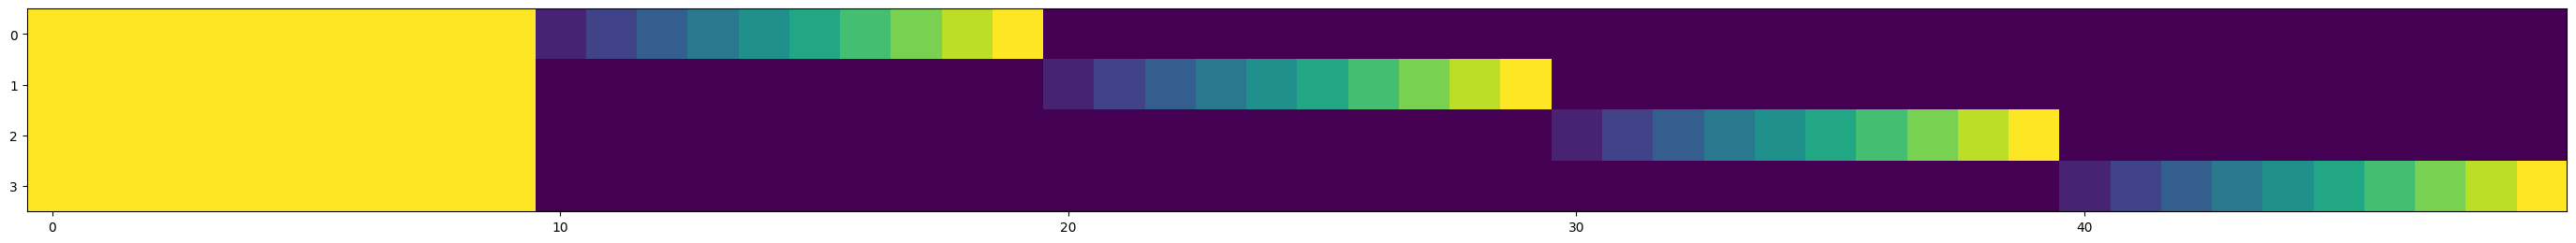

In [12]:
seq_class = []
total_tokens = 50
offset = 10

for i in range(4):
    temp = np.zeros(total_tokens)
    temp[:offset] = 1
    temp[(i+1)*offset:((i+2)*offset)] = np.arange(0.1,1.1,0.1)
    temp = temp/sum(temp)
    seq_class.append(temp)
    assert(sum(seq_class[i])==1)
plt.figure(figsize=(35,10))
plt.imshow(np.vstack(seq_class))

def sample_sequence(next_token,seq_len):
    '''
    function to sample a sequence based on p(l|m,n) for given m and n.
    '''
    query_tokens = [5,6,7,8]
    next_tokens = [1,2,3,4]
    if next_token==next_tokens[0]:
        context_tokens = np.random.choice(np.arange(50),p=seq_class[0],size=seq_len-2)
        seq = np.append(context_tokens,[query_tokens[0],next_token])
    if next_token==next_tokens[1]:
        context_tokens = np.random.choice(np.arange(50),p=seq_class[1],size=seq_len-2)
        seq = np.append(context_tokens,[query_tokens[1],next_token])
    if next_token==next_tokens[2]:
        context_tokens = np.random.choice(np.arange(50),p=seq_class[2],size=seq_len-2)
        seq = np.append(context_tokens,[query_tokens[2],next_token])
    if next_token==next_tokens[3]:
        context_tokens = np.random.choice(np.arange(50),p=seq_class[3],size=seq_len-2)
        seq = np.append(context_tokens,[query_tokens[3],next_token])
    return seq

def generate_data(batch_size,seq_len):
    batch_of_seq = []
    next_tokens = [1,2,3,4]
    for i in range(batch_size):
        next_token = np.random.choice(next_tokens,p=[0.25]*4)
        generated_seq = sample_sequence(next_token,seq_len)
        batch_of_seq.append(torch.tensor(generated_seq))
    return torch.vstack(batch_of_seq)


def analyse_model(model,batch_size,seq_len):
    test_inputs = generate_data(batch_size,seq_len)
    tinputs,tlabels  = test_inputs[:,:-1].to(device),test_inputs[:,-1].to(device)

    model.eval()
    with torch.no_grad():
        model_output,model_attention = model(tinputs)
    #model_output = nn.Softmax(dim=1)(model_output)

    common_tokens_attn = []
    distinct_tokens_attn = []
    for i in range(batch_size):
        indices_1 = torch.logical_and(tinputs[i]>=0,tinputs[i]<10)
        indices_2 = torch.logical_and(tinputs[i]>=10,tinputs[i]<50)
        common_tokens_attn.append(sum(model_attention[i][indices_1]).item())
        distinct_tokens_attn.append(sum(model_attention[i][indices_2]).item())
    return np.mean(common_tokens_attn),np.mean(distinct_tokens_attn)



In [13]:
def make_fixed_balanced_dataset(
    generate_data_fn,
    n_per_class: int,
    seq_len: int,
    generation_batch_size: int,
    seed: int,
    class_labels: Sequence[int] = (1, 2, 3, 4),
    max_batches: int = 100000,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Construct a fixed balanced dataset from the existing generate_data
    function.

    Assumes generate_data_fn(batch_size, seq_len) returns a tensor whose:
        data[:, :-1] = model input token IDs
        data[:, -1]  = target labels
    """
    set_all_seeds(seed)

    class_labels = tuple(int(label) for label in class_labels)

    token_buckets = {
        label: []
        for label in class_labels
    }

    counts = {
        label: 0
        for label in class_labels
    }

    n_batches_generated = 0

    while min(counts.values()) < n_per_class:
        if n_batches_generated >= max_batches:
            raise RuntimeError(
                "Could not collect enough examples for every class. "
                f"Current counts: {counts}"
            )

        data = generate_data_fn(
            generation_batch_size,
            seq_len,
        )

        if not torch.is_tensor(data):
            data = torch.as_tensor(data)

        data = data.detach().cpu().long()

        input_tokens = data[:, :-1]
        labels = data[:, -1]

        for label in class_labels:
            remaining = n_per_class - counts[label]

            if remaining <= 0:
                continue

            matching = torch.where(
                labels == label
            )[0]

            if matching.numel() == 0:
                continue

            matching = matching[:remaining]

            token_buckets[label].append(
                input_tokens.index_select(
                    0,
                    matching,
                )
            )

            counts[label] += int(
                matching.numel()
            )

        n_batches_generated += 1

    all_tokens = []
    all_labels = []

    for label in class_labels:
        class_tokens = torch.cat(
            token_buckets[label],
            dim=0,
        )[:n_per_class]

        class_labels_tensor = torch.full(
            (n_per_class,),
            fill_value=label,
            dtype=torch.long,
        )

        all_tokens.append(class_tokens)
        all_labels.append(class_labels_tensor)

    tokens = torch.cat(
        all_tokens,
        dim=0,
    )

    labels = torch.cat(
        all_labels,
        dim=0,
    )

    # Deterministic final dataset shuffle
    generator = torch.Generator()
    generator.manual_seed(seed + 1)

    permutation = torch.randperm(
        tokens.shape[0],
        generator=generator,
    )

    tokens = tokens.index_select(
        0,
        permutation,
    )

    labels = labels.index_select(
        0,
        permutation,
    )

    print("Dataset shape:", tokens.shape)
    print(
        "Class counts:",
        {
            label: int((labels == label).sum())
            for label in class_labels
        },
    )

    return tokens, labels

In [14]:
cfg = ExperimentConfig()

train_tokens, train_labels = make_fixed_balanced_dataset(
    generate_data_fn=generate_data,
    n_per_class=cfg.n_train_per_class,
    seq_len=cfg.seq_len,
    generation_batch_size=cfg.generation_batch_size,
    seed=cfg.train_dataset_seed,
)

test_tokens, test_labels = make_fixed_balanced_dataset(
    generate_data_fn=generate_data,
    n_per_class=cfg.n_test_per_class,
    seq_len=cfg.seq_len,
    generation_batch_size=cfg.generation_batch_size,
    seed=cfg.test_dataset_seed,
)

Dataset shape: torch.Size([1600, 255])
Class counts: {1: 400, 2: 400, 3: 400, 4: 400}
Dataset shape: torch.Size([2048, 255])
Class counts: {1: 512, 2: 512, 3: 512, 4: 512}


In [15]:
output_dir = Path(cfg.output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

dataset_path = output_dir / "fixed_train_test_dataset.pt"

torch.save(
    {
        "train_tokens": train_tokens,
        "train_labels": train_labels,
        "test_tokens": test_tokens,
        "test_labels": test_labels,
        "config": cfg.__dict__,
    },
    dataset_path,
)

print("Saved dataset to:", dataset_path)

Saved dataset to: lambda_grid_fixed_notebook/fixed_train_test_dataset.pt


In [16]:
# dataset_payload = torch.load(
#     dataset_path,
#     map_location="cpu",
# )

# train_tokens = dataset_payload["train_tokens"]
# train_labels = dataset_payload["train_labels"]

# test_tokens = dataset_payload["test_tokens"]
# test_labels = dataset_payload["test_labels"]

In [17]:
def iterate_fixed_batches(
    tokens: torch.Tensor,
    labels: torch.Tensor,
    batch_size: int,
    permutation: np.ndarray,
):
    """
    Yield minibatches according to a supplied permutation.
    """
    n_examples = int(tokens.shape[0])

    for start in range(
        0,
        n_examples,
        batch_size,
    ):
        batch_indices_np = permutation[
            start:start + batch_size
        ]

        batch_indices = torch.from_numpy(
            np.asarray(
                batch_indices_np,
                dtype=np.int64,
            )
        )

        yield (
            tokens.index_select(
                0,
                batch_indices,
            ),
            labels.index_select(
                0,
                batch_indices,
            ),
        )

In [18]:
def train_one_model(
    model: Net_p1,
    train_tokens: torch.Tensor,
    train_labels: torch.Tensor,
    device: torch.device,
    n_epochs: int,
    batch_size: int,
    learning_rate: float,
    momentum: float,
    weight_decay: float,
    record_every_epochs: int,
    shuffle_seed: int,
    lambda_qk: float,
    lambda_ov: float,
    model_seed: int,
) -> Tuple[pd.DataFrame, List[float]]:
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=learning_rate,
        momentum=momentum,
        weight_decay=weight_decay,
    )

    shuffle_rng = np.random.default_rng(
        shuffle_seed
    )

    trajectory_rows = []
    epoch_losses = []

    optimization_step = 0

    # Initial circuit state
    initial_metrics = model.circuit_metrics()

    trajectory_rows.append(
        {
            "model_seed": model_seed,
            "lambda_qk": float(lambda_qk),
            "lambda_ov": float(lambda_ov),
            "epoch": 0,
            "optimization_step": 0,
            "train_loss": np.nan,
            **initial_metrics,
        }
    )

    n_train = int(train_tokens.shape[0])

    progress = tqdm(
        range(1, n_epochs + 1),
        desc=(
            f"QK={lambda_qk:g}, "
            f"OV={lambda_ov:g}, "
            f"seed={model_seed}"
        ),
        leave=False,
    )

    for epoch in progress:
        model.train()

        # Using the same shuffle_seed for a particular model seed
        # guarantees identical minibatches across lambda pairs.
        permutation = shuffle_rng.permutation(
            n_train
        )

        total_loss = 0.0
        total_examples = 0

        for token_batch_cpu, label_batch_cpu in iterate_fixed_batches(
            tokens=train_tokens,
            labels=train_labels,
            batch_size=batch_size,
            permutation=permutation,
        ):
            token_batch = token_batch_cpu.to(
                device
            )

            label_batch = label_batch_cpu.to(
                device
            )

            input_batch = F.one_hot(
                token_batch,
                num_classes=50,
            ).float()

            optimizer.zero_grad()

            logits, _ = model(input_batch)

            loss = criterion(
                logits,
                label_batch,
            )

            loss.backward()
            optimizer.step()

            actual_batch_size = int(
                label_batch.shape[0]
            )

            total_loss += (
                float(loss.item())
                * actual_batch_size
            )

            total_examples += (
                actual_batch_size
            )

            optimization_step += 1

        mean_epoch_loss = (
            total_loss
            / max(total_examples, 1)
        )

        epoch_losses.append(
            mean_epoch_loss
        )

        progress.set_postfix(
            loss=f"{mean_epoch_loss:.5f}"
        )

        if (
            epoch % record_every_epochs == 0
            or epoch == n_epochs
        ):
            metrics = model.circuit_metrics()

            trajectory_rows.append(
                {
                    "model_seed": model_seed,
                    "lambda_qk": float(lambda_qk),
                    "lambda_ov": float(lambda_ov),
                    "epoch": epoch,
                    "optimization_step":
                        optimization_step,
                    "train_loss":
                        mean_epoch_loss,
                    **metrics,
                }
            )

    return (
        pd.DataFrame(trajectory_rows),
        epoch_losses,
    )

In [19]:
@torch.no_grad()
def evaluate_model(
    model: Net_p1,
    test_tokens: torch.Tensor,
    test_labels: torch.Tensor,
    device: torch.device,
    eval_batch_size: int,
    vocab_size: int = 50,
) -> Dict[str, object]:
    model.eval()

    all_distinct_mass = []
    all_correct_probability = []
    all_entropy_bits = []
    all_entropy_normalized = []
    all_uniform_distinct_mass = []

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    n_test = int(test_tokens.shape[0])

    for start in range(
        0,
        n_test,
        eval_batch_size,
    ):
        token_batch = test_tokens[
            start:start + eval_batch_size
        ].to(device)

        label_batch = test_labels[
            start:start + eval_batch_size
        ].to(device)

        inputs = F.one_hot(
            token_batch,
            num_classes=vocab_size,
        ).float()

        logits, attention = model(inputs)

        probabilities = torch.softmax(
            logits,
            dim=-1,
        )

        batch_size_actual = int(
            label_batch.shape[0]
        )

        row_indices = torch.arange(
            batch_size_actual,
            device=device,
        )

        correct_probability = probabilities[
            row_indices,
            label_batch,
        ]

        predicted_labels = logits.argmax(
            dim=-1
        )

        # Distinct tokens have IDs 10,...,49.
        distinct_mask = token_batch > 9

        distinct_attention_mass = (
            attention
            * distinct_mask.float()
        ).sum(dim=-1)

        # Expected distinct mass under uniform attention.
        uniform_distinct_mass = (
            distinct_mask.float().mean(dim=-1)
        )

        attention_safe = attention.clamp_min(
            1e-12
        )

        entropy_bits = -(
            attention_safe
            * torch.log2(attention_safe)
        ).sum(dim=-1)

        maximum_entropy = math.log2(
            attention.shape[-1]
        )

        entropy_normalized = (
            entropy_bits
            / maximum_entropy
        )

        total_loss += float(
            F.cross_entropy(
                logits,
                label_batch,
                reduction="sum",
            ).item()
        )

        total_correct += int(
            (
                predicted_labels
                == label_batch
            ).sum().item()
        )

        total_examples += batch_size_actual

        all_distinct_mass.append(
            distinct_attention_mass.cpu().numpy()
        )

        all_correct_probability.append(
            correct_probability.cpu().numpy()
        )

        all_entropy_bits.append(
            entropy_bits.cpu().numpy()
        )

        all_entropy_normalized.append(
            entropy_normalized.cpu().numpy()
        )

        all_uniform_distinct_mass.append(
            uniform_distinct_mass.cpu().numpy()
        )

    distinct_mass = np.concatenate(
        all_distinct_mass
    )

    correct_probability = np.concatenate(
        all_correct_probability
    )

    entropy_bits = np.concatenate(
        all_entropy_bits
    )

    entropy_normalized = np.concatenate(
        all_entropy_normalized
    )

    uniform_distinct_mass = np.concatenate(
        all_uniform_distinct_mass
    )

    return {
        "test_loss":
            total_loss / total_examples,

        "test_accuracy":
            total_correct / total_examples,

        "correct_probability_mean":
            float(correct_probability.mean()),

        "correct_probability_std":
            float(correct_probability.std()),

        "distinct_mass_mean":
            float(distinct_mass.mean()),

        "distinct_mass_std":
            float(distinct_mass.std()),

        "uniform_distinct_mass_mean":
            float(uniform_distinct_mass.mean()),

        "distinct_mass_excess_mean":
            float(
                (
                    distinct_mass
                    - uniform_distinct_mass
                ).mean()
            ),

        "entropy_bits_mean":
            float(entropy_bits.mean()),

        "entropy_bits_std":
            float(entropy_bits.std()),

        "entropy_normalized_mean":
            float(entropy_normalized.mean()),

        "entropy_normalized_std":
            float(entropy_normalized.std()),

        # Raw arrays for per-run distribution heatmaps
        "distinct_mass_values":
            distinct_mass,

        "correct_probability_values":
            correct_probability,

        "entropy_bits_values":
            entropy_bits,

        "entropy_normalized_values":
            entropy_normalized,
    }

In [20]:
def compute_distribution_histogram(
    distinct_mass: np.ndarray,
    correct_probability: np.ndarray,
    edges: Optional[np.ndarray] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute a two-dimensional percentage histogram.

    Horizontal variable:
        distinct-token attention mass

    Vertical variable:
        probability assigned to the correct label

    Returns
    -------
    histogram_percentage:
        Shape (n_bins, n_bins). The entries sum to 100.

    edges:
        Histogram bin edges.
    """
    distinct_mass = np.asarray(
        distinct_mass,
        dtype=np.float64,
    ).reshape(-1)

    correct_probability = np.asarray(
        correct_probability,
        dtype=np.float64,
    ).reshape(-1)

    if distinct_mass.shape != correct_probability.shape:
        raise ValueError(
            "distinct_mass and correct_probability must "
            "contain the same number of examples."
        )

    if distinct_mass.size == 0:
        raise ValueError("Cannot construct a histogram from empty arrays.")

    if not np.all(np.isfinite(distinct_mass)):
        raise ValueError("distinct_mass contains NaN or infinite values.")

    if not np.all(np.isfinite(correct_probability)):
        raise ValueError(
            "correct_probability contains NaN or infinite values."
        )

    # Small numerical errors can produce values such as 1.0000001.
    distinct_mass = np.clip(
        distinct_mass,
        0.0,
        1.0,
    )

    correct_probability = np.clip(
        correct_probability,
        0.0,
        1.0,
    )

    if edges is None:
        # The last edge is slightly above 1 so values exactly equal
        # to 1 are guaranteed to lie in the final bin.
        edges = np.array(
            [
                0.0,
                0.2,
                0.4,
                0.6,
                0.8,
                np.nextafter(1.0, 2.0),
            ],
            dtype=np.float64,
        )
    else:
        edges = np.asarray(
            edges,
            dtype=np.float64,
        )

    histogram, _, _ = np.histogram2d(
        distinct_mass,
        correct_probability,
        bins=(edges, edges),
    )

    total_examples = histogram.sum()

    if total_examples == 0:
        raise RuntimeError(
            "The histogram contains no examples. Check the values "
            "and histogram edges."
        )

    histogram_percentage = (
        100.0 * histogram / total_examples
    )

    # Every test example should be represented exactly once.
    if not np.isclose(
        histogram_percentage.sum(),
        100.0,
        atol=1e-8,
    ):
        raise RuntimeError(
            "Histogram percentages do not sum to 100."
        )

    return histogram_percentage, edges

In [21]:
def plot_distribution_heatmap(
    histogram_mean: np.ndarray,
    histogram_std: np.ndarray,
    edges: np.ndarray,
    lambda_qk: float,
    lambda_ov: float,
    mass_mean: float,
    entropy_mean: float,
    output_path: Optional[Path] = None,
    show: bool = True,
    vmin: float = 0.0,
    vmax: float = 100.0,
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Plot mean percentage per histogram bin.

    histogram_mean:
        Mean percentage histogram across seeds.

    histogram_std:
        Standard deviation of percentage histograms across seeds.

    The histogram is transposed so:
        x-axis = distinct-token attention mass
        y-axis = correct-label probability
    """
    histogram_mean = np.asarray(
        histogram_mean,
        dtype=np.float64,
    )

    histogram_std = np.asarray(
        histogram_std,
        dtype=np.float64,
    )

    edges = np.asarray(
        edges,
        dtype=np.float64,
    )

    if histogram_mean.ndim != 2:
        raise ValueError(
            "histogram_mean must be a two-dimensional matrix."
        )

    if histogram_mean.shape != histogram_std.shape:
        raise ValueError(
            "histogram_mean and histogram_std must have the same shape."
        )

    expected_bins = len(edges) - 1

    if histogram_mean.shape != (
        expected_bins,
        expected_bins,
    ):
        raise ValueError(
            f"Expected histogram shape "
            f"({expected_bins}, {expected_bins}), "
            f"but received {histogram_mean.shape}."
        )

    if not np.isclose(
        histogram_mean.sum(),
        100.0,
        atol=1e-5,
    ):
        raise ValueError(
            "histogram_mean should sum to 100 percent. "
            f"Current sum: {histogram_mean.sum():.6f}"
        )

    # Construct mean or mean ± standard-deviation annotations.
    annotation = np.empty_like(
        histogram_mean,
        dtype=object,
    )

    has_multiple_seed_variation = np.any(
        histogram_std > 1e-12
    )

    for i in range(histogram_mean.shape[0]):
        for j in range(histogram_mean.shape[1]):
            if has_multiple_seed_variation:
                annotation[i, j] = (
                    f"{histogram_mean[i, j]:.1f}"
                    f"\n±{histogram_std[i, j]:.1f}"
                )
            else:
                annotation[i, j] = (
                    f"{histogram_mean[i, j]:.1f}"
                )

    interval_labels = []

    for left, right in zip(
        edges[:-1],
        edges[1:],
    ):
        interval_labels.append(
            f"{left:.1f}–{min(right, 1.0):.1f}"
        )

    fig, ax = plt.subplots(
        figsize=(6.5, 6.0)
    )

    sns.heatmap(
        # Transpose: rows become correct-probability bins and
        # columns become attention-mass bins.
        histogram_mean.T,

        # Annotation must be transposed in the same way.
        annot=annotation.T,

        fmt="",
        cmap="coolwarm",

        vmin=vmin,
        vmax=vmax,

        square=True,
        linewidths=0.5,
        linecolor="white",

        cbar=True,
        cbar_kws={
            "label": "Percentage of test examples",
        },

        annot_kws={
            "size": 11,
        },

        ax=ax,
    )

    # seaborn places row zero at the top. Invert so the lowest
    # correct-probability interval appears at the bottom.
    ax.invert_yaxis()

    ax.set_xticklabels(
        interval_labels,
        rotation=35,
        ha="right",
    )

    ax.set_yticklabels(
        interval_labels,
        rotation=0,
    )

    ax.tick_params(
        axis="both",
        labelsize=11,
    )

    ax.set_xlabel(
        "Distinct Token Attention Mass",
        fontsize=14,
        fontweight="bold",
    )

    ax.set_ylabel(
        "Correct Label Probability",
        fontsize=14,
        fontweight="bold",
    )

    ax.set_title(
        rf"$\lambda_{{QK}}={lambda_qk:g}$, "
        rf"$\lambda_{{OV}}={lambda_ov:g}$"
        "\n"
        f"Mass = {mass_mean:.3f}, "
        f"Entropy = {entropy_mean:.3f}",
        fontsize=14,
        fontweight="bold",
    )

    fig.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)

        output_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        fig.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight",
        )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax

In [22]:
def summarize_trajectory_column(
    trajectory_df: pd.DataFrame,
    column: str,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    grouped = trajectory_df.groupby(
        "epoch"
    )[column]

    epochs = grouped.mean().index.to_numpy()
    mean = grouped.mean().to_numpy()

    std = (
        grouped.std(ddof=0)
        .fillna(0.0)
        .to_numpy()
    )

    return epochs, mean, std

In [23]:
def plot_product_movement(
    trajectory_df: pd.DataFrame,
    lambda_qk: float,
    lambda_ov: float,
    output_path: Optional[Path] = None,
    show: bool = True,
) -> None:
    epochs, qk_mean, qk_std = (
        summarize_trajectory_column(
            trajectory_df,
            "qk_product_rel_movement",
        )
    )

    _, ov_mean, ov_std = (
        summarize_trajectory_column(
            trajectory_df,
            "ov_product_rel_movement",
        )
    )

    fig, ax = plt.subplots(
        figsize=(7, 5)
    )

    ax.plot(
        epochs,
        qk_mean,
        label="QK circuit",
    )

    ax.fill_between(
        epochs,
        qk_mean - qk_std,
        qk_mean + qk_std,
        alpha=0.2,
    )

    ax.plot(
        epochs,
        ov_mean,
        label="OV circuit",
    )

    ax.fill_between(
        epochs,
        ov_mean - ov_std,
        ov_mean + ov_std,
        alpha=0.2,
    )

    ax.set_xlabel("Epoch")

    ax.set_ylabel(
        "Relative effective-product movement"
    )

    ax.set_title(
        rf"$\lambda_{{QK}}={lambda_qk:g}$, "
        rf"$\lambda_{{OV}}={lambda_ov:g}$"
    )

    ax.legend()
    fig.tight_layout()

    if output_path is not None:
        fig.savefig(
            output_path,
            bbox_inches="tight",
        )

    if show:
        plt.show()
    else:
        plt.close(fig)

In [24]:
def plot_balancedness_drift(
    trajectory_df: pd.DataFrame,
    lambda_qk: float,
    lambda_ov: float,
    output_path: Optional[Path] = None,
    show: bool = True,
) -> None:
    epochs, qk_mean, qk_std = (
        summarize_trajectory_column(
            trajectory_df,
            "qk_balance_normalized_drift",
        )
    )

    _, ov_mean, ov_std = (
        summarize_trajectory_column(
            trajectory_df,
            "ov_balance_normalized_drift",
        )
    )

    qk_lower = np.maximum(
        qk_mean - qk_std,
        1e-16,
    )

    qk_upper = np.maximum(
        qk_mean + qk_std,
        1e-16,
    )

    ov_lower = np.maximum(
        ov_mean - ov_std,
        1e-16,
    )

    ov_upper = np.maximum(
        ov_mean + ov_std,
        1e-16,
    )

    fig, ax = plt.subplots(
        figsize=(7, 5)
    )

    ax.plot(
        epochs,
        np.maximum(qk_mean, 1e-16),
        label="QK balancedness",
    )

    ax.fill_between(
        epochs,
        qk_lower,
        qk_upper,
        alpha=0.2,
    )

    ax.plot(
        epochs,
        np.maximum(ov_mean, 1e-16),
        label="OV balancedness",
    )

    ax.fill_between(
        epochs,
        ov_lower,
        ov_upper,
        alpha=0.2,
    )

    ax.set_yscale("log")

    ax.set_xlabel("Epoch")

    ax.set_ylabel(
        "Gram-normalized invariant drift"
    )

    ax.set_title(
        rf"$\lambda_{{QK}}={lambda_qk:g}$, "
        rf"$\lambda_{{OV}}={lambda_ov:g}$"
    )

    ax.legend()
    fig.tight_layout()

    if output_path is not None:
        fig.savefig(
            output_path,
            bbox_inches="tight",
        )

    if show:
        plt.show()
    else:
        plt.close(fig)

In [25]:
def plot_lambda_metric_grid(
    aggregate_df: pd.DataFrame,
    lambda_qk_values: Sequence[float],
    lambda_ov_values: Sequence[float],
    metric_column: str,
    title: str,
    colorbar_label: str,
    output_path: Optional[Path] = None,
    show: bool = True,
) -> None:
    pivot = aggregate_df.pivot(
        index="lambda_qk",
        columns="lambda_ov",
        values=metric_column,
    )

    pivot = pivot.reindex(
        index=[
            float(value)
            for value in lambda_qk_values
        ],
        columns=[
            float(value)
            for value in lambda_ov_values
        ],
    )

    matrix = pivot.to_numpy()

    fig, ax = plt.subplots(
        figsize=(
            max(7, len(lambda_ov_values) * 0.65),
            max(6, len(lambda_qk_values) * 0.55),
        )
    )

    image = ax.imshow(
        matrix,
        origin="lower",
        aspect="auto",
    )

    ax.set_xticks(
        np.arange(len(lambda_ov_values))
    )

    ax.set_yticks(
        np.arange(len(lambda_qk_values))
    )

    ax.set_xticklabels(
        [
            f"{value:g}"
            for value in lambda_ov_values
        ],
        rotation=45,
        ha="right",
    )

    ax.set_yticklabels(
        [
            f"{value:g}"
            for value in lambda_qk_values
        ]
    )

    for row in range(matrix.shape[0]):
        for column in range(
            matrix.shape[1]
        ):
            if np.isfinite(
                matrix[row, column]
            ):
                ax.text(
                    column,
                    row,
                    f"{matrix[row, column]:.3f}",
                    ha="center",
                    va="center",
                    fontsize=7,
                )

    ax.set_xlabel(r"$\lambda_{OV}$")
    ax.set_ylabel(r"$\lambda_{QK}$")
    ax.set_title(title)

    colorbar = fig.colorbar(
        image,
        ax=ax,
    )

    colorbar.set_label(
        colorbar_label
    )

    fig.tight_layout()

    if output_path is not None:
        fig.savefig(
            output_path,
            bbox_inches="tight",
        )

    if show:
        plt.show()
    else:
        plt.close(fig)

In [26]:
def lambda_tag(value: float) -> str:
    value = float(value)

    if value.is_integer():
        return str(int(value))

    return str(value).replace(".", "p")

In [27]:
def run_lambda_grid(
    cfg: ExperimentConfig,
    train_tokens: torch.Tensor,
    train_labels: torch.Tensor,
    test_tokens: torch.Tensor,
    test_labels: torch.Tensor,
    device: torch.device,
):
    output_dir = Path(cfg.output_dir)

    checkpoint_dir = (
        output_dir / "checkpoints"
    )

    pair_heatmap_dir = (
        output_dir / "pair_heatmaps"
    )

    product_drift_dir = (
        output_dir / "product_movement"
    )

    balance_drift_dir = (
        output_dir / "balancedness_drift"
    )

    for directory in (
        output_dir,
        checkpoint_dir,
        pair_heatmap_dir,
        product_drift_dir,
        balance_drift_dir,
    ):
        directory.mkdir(
            parents=True,
            exist_ok=True,
        )

    all_final_rows = []
    all_trajectory_frames = []

    total_pairs = (
        len(cfg.lambda_qk_values)
        * len(cfg.lambda_ov_values)
    )

    pair_index = 0

    for lambda_qk in cfg.lambda_qk_values:
        for lambda_ov in cfg.lambda_ov_values:
            pair_index += 1

            print(
                "\n"
                f"[{pair_index}/{total_pairs}] "
                f"lambda_QK={lambda_qk}, "
                f"lambda_OV={lambda_ov}"
            )

            pair_histograms = []
            pair_final_rows = []
            pair_trajectory_frames = []

            for model_seed in cfg.model_seeds:
                set_all_seeds(model_seed)

                model = Net_p1(
                    lmda_qk=lambda_qk,
                    lmda_ov=lambda_ov,
                    seed=model_seed,
                    d_model=50,
                    d_head=50,
                    d_value=50,
                    d_out=50,
                    sigma_qk=cfg.sigma_qk,
                    sigma_ov=cfg.sigma_ov,
                ).float().to(device)

                print(
                    f"Initialization check, "
                    f"seed={model_seed}"
                )

                initialization_metrics = (
                    model.verify_initialization()
                )

                trajectory_df, epoch_losses = (
                    train_one_model(
                        model=model,
                        train_tokens=train_tokens,
                        train_labels=train_labels,
                        device=device,
                        n_epochs=cfg.n_epochs,
                        batch_size=(
                            cfg.train_batch_size
                        ),
                        learning_rate=(
                            cfg.learning_rate
                        ),
                        momentum=cfg.momentum,
                        weight_decay=(
                            cfg.weight_decay
                        ),
                        record_every_epochs=(
                            cfg.record_every_epochs
                        ),
                        shuffle_seed=(
                            cfg.shuffle_seed_offset
                            + model_seed
                        ),
                        lambda_qk=lambda_qk,
                        lambda_ov=lambda_ov,
                        model_seed=model_seed,
                    )
                )

                evaluation = evaluate_model(
                    model=model,
                    test_tokens=test_tokens,
                    test_labels=test_labels,
                    device=device,
                    eval_batch_size=(
                        cfg.eval_batch_size
                    ),
                    vocab_size=50,
                )

                final_circuit_metrics = (
                    model.circuit_metrics()
                )

                final_row = {
                    "model_seed":
                        model_seed,

                    "lambda_qk":
                        float(lambda_qk),

                    "lambda_ov":
                        float(lambda_ov),

                    "final_train_loss":
                        float(
                            epoch_losses[-1]
                        ),

                    "test_loss":
                        evaluation["test_loss"],

                    "test_accuracy":
                        evaluation[
                            "test_accuracy"
                        ],

                    "correct_probability_mean":
                        evaluation[
                            "correct_probability_mean"
                        ],

                    "distinct_mass_mean":
                        evaluation[
                            "distinct_mass_mean"
                        ],

                    "uniform_distinct_mass_mean":
                        evaluation[
                            "uniform_distinct_mass_mean"
                        ],

                    "distinct_mass_excess_mean":
                        evaluation[
                            "distinct_mass_excess_mean"
                        ],

                    "entropy_bits_mean":
                        evaluation[
                            "entropy_bits_mean"
                        ],

                    "entropy_normalized_mean":
                        evaluation[
                            "entropy_normalized_mean"
                        ],

                    **initialization_metrics,
                    **final_circuit_metrics,
                }

                pair_final_rows.append(
                    final_row
                )

                all_final_rows.append(
                    final_row
                )

                pair_trajectory_frames.append(
                    trajectory_df
                )

                all_trajectory_frames.append(
                    trajectory_df
                )

                histogram, histogram_edges = (
                    compute_distribution_histogram(
                        distinct_mass=(
                            evaluation[
                                "distinct_mass_values"
                            ]
                        ),
                        correct_probability=(
                            evaluation[
                                "correct_probability_values"
                            ]
                        ),
                    )
                )

                pair_histograms.append(
                    histogram
                )

                if cfg.save_checkpoints:
                    checkpoint_name = (
                        f"model_seed{model_seed}"
                        f"_qk{lambda_tag(lambda_qk)}"
                        f"_ov{lambda_tag(lambda_ov)}"
                        ".pt"
                    )

                    torch.save(
                        {
                            "model_state_dict":
                                model.state_dict(),

                            "model_seed":
                                model_seed,

                            "lambda_qk":
                                float(lambda_qk),

                            "lambda_ov":
                                float(lambda_ov),

                            "config":
                                cfg.__dict__,
                        },
                        checkpoint_dir
                        / checkpoint_name,
                    )

                del model

                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

            pair_final_df = pd.DataFrame(
                pair_final_rows
            )

            pair_trajectory_df = pd.concat(
                pair_trajectory_frames,
                ignore_index=True,
            )

            histogram_stack = np.stack(
                pair_histograms,
                axis=0,
            )

            histogram_mean = (
                histogram_stack.mean(axis=0)
            )

            histogram_std = (
                histogram_stack.std(axis=0)
            )

            qk_tag = lambda_tag(lambda_qk)
            ov_tag = lambda_tag(lambda_ov)

            plot_distribution_heatmap(
                histogram_mean=histogram_mean,
                histogram_std=histogram_std,
                edges=histogram_edges,
                lambda_qk=lambda_qk,
                lambda_ov=lambda_ov,
                mass_mean=(
                    pair_final_df[
                        "distinct_mass_mean"
                    ].mean()
                ),
                entropy_mean=(
                    pair_final_df[
                        "entropy_normalized_mean"
                    ].mean()
                ),
                output_path=(
                    pair_heatmap_dir
                    / (
                        f"heatmap_qk_{qk_tag}"
                        f"_ov_{ov_tag}.pdf"
                    )
                ),
                show=False,
            )

            plot_product_movement(
                trajectory_df=(
                    pair_trajectory_df
                ),
                lambda_qk=lambda_qk,
                lambda_ov=lambda_ov,
                output_path=(
                    product_drift_dir
                    / (
                        f"product_qk_{qk_tag}"
                        f"_ov_{ov_tag}.pdf"
                    )
                ),
                show=False,
            )

            plot_balancedness_drift(
                trajectory_df=(
                    pair_trajectory_df
                ),
                lambda_qk=lambda_qk,
                lambda_ov=lambda_ov,
                output_path=(
                    balance_drift_dir
                    / (
                        f"balance_qk_{qk_tag}"
                        f"_ov_{ov_tag}.pdf"
                    )
                ),
                show=False,
            )

            # Incremental saving protects long runs.
            pd.DataFrame(
                all_final_rows
            ).to_csv(
                output_dir
                / "final_metrics_per_seed.csv",
                index=False,
            )

            pd.concat(
                all_trajectory_frames,
                ignore_index=True,
            ).to_csv(
                output_dir
                / "circuit_trajectories.csv",
                index=False,
            )

    final_per_seed_df = pd.DataFrame(
        all_final_rows
    )

    trajectory_df = pd.concat(
        all_trajectory_frames,
        ignore_index=True,
    )

    metrics_to_aggregate = [
        "final_train_loss",
        "test_loss",
        "test_accuracy",
        "correct_probability_mean",
        "distinct_mass_mean",
        "uniform_distinct_mass_mean",
        "distinct_mass_excess_mean",
        "entropy_bits_mean",
        "entropy_normalized_mean",
        "qk_product_rel_movement",
        "ov_product_rel_movement",
        "qk_balance_normalized_drift",
        "ov_balance_normalized_drift",
    ]

    aggregate_rows = []

    for (
        lambda_qk,
        lambda_ov,
    ), group in final_per_seed_df.groupby(
        ["lambda_qk", "lambda_ov"]
    ):
        row = {
            "lambda_qk":
                float(lambda_qk),

            "lambda_ov":
                float(lambda_ov),
        }

        for metric in metrics_to_aggregate:
            row[metric] = float(
                group[metric].mean()
            )

            row[metric + "_std"] = float(
                group[metric].std(ddof=0)
            )

        aggregate_rows.append(row)

    aggregate_df = pd.DataFrame(
        aggregate_rows
    )

    aggregate_df.to_csv(
        output_dir
        / "final_metrics_aggregate.csv",
        index=False,
    )

    plot_lambda_metric_grid(
        aggregate_df=aggregate_df,
        lambda_qk_values=(
            cfg.lambda_qk_values
        ),
        lambda_ov_values=(
            cfg.lambda_ov_values
        ),
        metric_column="distinct_mass_mean",
        title=(
            "Distinct-token attention mass"
        ),
        colorbar_label="Attention mass",
        output_path=(
            output_dir
            / "grid_distinct_attention_mass.pdf"
        ),
        show=False,
    )

    plot_lambda_metric_grid(
        aggregate_df=aggregate_df,
        lambda_qk_values=(
            cfg.lambda_qk_values
        ),
        lambda_ov_values=(
            cfg.lambda_ov_values
        ),
        metric_column=(
            "entropy_normalized_mean"
        ),
        title=(
            "Normalized attention entropy"
        ),
        colorbar_label=(
            "Normalized entropy"
        ),
        output_path=(
            output_dir
            / "grid_attention_entropy.pdf"
        ),
        show=False,
    )

    plot_lambda_metric_grid(
        aggregate_df=aggregate_df,
        lambda_qk_values=(
            cfg.lambda_qk_values
        ),
        lambda_ov_values=(
            cfg.lambda_ov_values
        ),
        metric_column=(
            "correct_probability_mean"
        ),
        title=(
            "Correct-label probability"
        ),
        colorbar_label=(
            "Correct-label probability"
        ),
        output_path=(
            output_dir
            / "grid_correct_probability.pdf"
        ),
        show=False,
    )

    return (
        final_per_seed_df,
        aggregate_df,
        trajectory_df,
    )

In [28]:
device = torch.device("cuda")

print("Device:", device)

Device: cuda


In [29]:
full_cfg = ExperimentConfig(
    lambda_qk_values=(
        0,2,5, 10, 20, 40, 60, 80,
        100, 120, 140, 160, 180, 200,
    ),

    lambda_ov_values=(
        0,2,5,10, 20, 40, 60, 80,
        100, 120, 140, 160, 180, 200,
    ),

    model_seeds=(
        1234,
        #1235,
        #1236,
        #1237,
        #1238,
    ),

    seq_len=256,

    n_train_per_class=400,
    n_test_per_class=512,

    train_batch_size=32,
    eval_batch_size=256,

    n_epochs=1200,
    record_every_epochs=20,

    learning_rate=1e-2,

    sigma_qk=1.0,
    sigma_ov=1.0,

    output_dir="lambda_grid_full",
)

In [30]:
import seaborn as sns

In [31]:
final_per_seed_df, aggregate_df, trajectory_df = (
    run_lambda_grid(
        cfg=full_cfg,
        train_tokens=train_tokens,
        train_labels=train_labels,
        test_tokens=test_tokens,
        test_labels=test_labels,
        device=device,
    )
)


[1/196] lambda_QK=0, lambda_OV=0
Initialization check, seed=1234
qk_product_relative_error: 7.774e-08
qk_balance_absolute_error: 1.578e-06
qk_balance_relative_error: 1.578e-06
ov_product_relative_error: 7.664e-08
ov_balance_absolute_error: 1.554e-06
ov_balance_relative_error: 1.554e-06


QK=0, OV=0, seed=1234:   0%|          | 0/1200 [00:00<?, ?it/s]


[2/196] lambda_QK=0, lambda_OV=2
Initialization check, seed=1234
qk_product_relative_error: 7.774e-08
qk_balance_absolute_error: 1.578e-06
qk_balance_relative_error: 1.578e-06
ov_product_relative_error: 8.219e-08
ov_balance_absolute_error: 1.997e-06
ov_balance_relative_error: 1.412e-07


QK=0, OV=2, seed=1234:   0%|          | 0/1200 [00:00<?, ?it/s]


[3/196] lambda_QK=0, lambda_OV=5
Initialization check, seed=1234
qk_product_relative_error: 7.774e-08
qk_balance_absolute_error: 1.578e-06
qk_balance_relative_error: 1.578e-06
ov_product_relative_error: 8.719e-08
ov_balance_absolute_error: 3.543e-06
ov_balance_relative_error: 1.002e-07


...

QK=200, OV=160, seed=1234:   0%|          | 0/1200 [00:00<?, ?it/s]


[195/196] lambda_QK=200, lambda_OV=180
Initialization check, seed=1234
qk_product_relative_error: 9.022e-08
qk_balance_absolute_error: 1.280e-04
qk_balance_relative_error: 9.053e-08
ov_product_relative_error: 9.303e-08
ov_balance_absolute_error: 1.097e-04
ov_balance_relative_error: 8.617e-08


QK=200, OV=180, seed=1234:   0%|          | 0/1200 [00:00<?, ?it/s]


[196/196] lambda_QK=200, lambda_OV=200
Initialization check, seed=1234
qk_product_relative_error: 9.022e-08
qk_balance_absolute_error: 1.280e-04
qk_balance_relative_error: 9.053e-08
ov_product_relative_error: 9.058e-08
ov_balance_absolute_error: 1.290e-04
ov_balance_relative_error: 9.125e-08


QK=200, OV=200, seed=1234:   0%|          | 0/1200 [00:00<?, ?it/s]